# Аналіз маркетингової кампанії банку — Версія 2.0
## Прогнозування підписки на строковий депозит

**Виконавець:** Сімоненко Анастасія  
**Версія:** 2.0 — розширений аналіз  

**Покращення порівняно з v1.0:**
- Feature Engineering: 12 нових ознак замість 6 (логарифми, взаємодії, бінарні прапори)
- Глибокий EDA: Pairplot, кореляції з ціллю, сегментний аналіз, аналіз балансу
- Крос-валідація (5-fold Stratified) + порівняння моделей з duration та без
- Feature Importance (Gini) + SHAP values (beeswarm + bar)
- Profit Curve, Lift Curve, Cost-Benefit аналіз з оптимальним порогом

**Набір даних:** 45 211 записів | 16 вихідних ознак → 25 після FE | Бінарна ціль (`y`)

---
## Крок 1. Завантаження та початкова перевірка даних

**Обґрунтування:** Перед будь-яким аналізом необхідно зрозуміти структуру даних — кількість спостережень, типи змінних, наявність пропусків. Це визначає весь подальший план роботи. Без цього кроку ризикуємо будувати аналіз на «брудних» даних і отримати недостовірні результати.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import shap, copy

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

df = pd.read_csv('data.txt', sep='\t')
# pandas 2+ може читати рядкові колонки як StringDtype — приводимо до object
for c in df.select_dtypes(include='string').columns:
    df[c] = df[c].astype('object')

print(f'Розмір датасету: {df.shape}')
print(f'Колонки: {list(df.columns)}')
print(f'Типи даних:\n{df.dtypes}')
df.head()

---
## Крок 2. Очищення даних

**Обґрунтування:** У датасеті є два типи прихованих пропусків:
- Рядок `'unknown'` у категоріальних колонках — не є окремою категорією, це відсутнє значення
- Значення `-1` у `pdays` — семантично означає «ніколи не контактувались», не є числовим пропуском

Обробка кожного з них відповідно до бізнес-логіки є критичною для коректності моделі. Механічне видалення рядків призвело б до втрати від 5% до 30% даних залежно від колонки.

In [ ]:
# Перевірка прихованих пропусків
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("=== Кількість 'unknown' ===")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:15s}: {n:5d} ({n/len(df)*100:.1f}%)')

# Очищення
mode_contact = df.loc[df['contact'] != 'unknown', 'contact'].mode()[0]
df['contact'].replace('unknown', mode_contact, inplace=True)
df['poutcome'].replace('unknown', 'not_contacted', inplace=True)
for col in ['education', 'job']:
    mv = df.loc[df[col] != 'unknown', col].mode()[0]
    df[col].replace('unknown', mv, inplace=True)

# pdays: -1 → 0 + бінарний прапор
df['previously_contacted'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)
df['y_bin'] = (df['y'] == 'yes').astype(int)

print(f'\nДублікатів: {df.duplicated().sum()}')
print(f'Частка позитивного класу: {df["y_bin"].mean()*100:.1f}%')

---
## Крок 3. Feature Engineering v2.0 — 12 нових ознак

**Обґрунтування:** Сирі дані рідко оптимальні для моделей. Якісне конструювання ознак часто дає більший приріст якості, ніж вибір складнішого алгоритму. У версії 2.0 додано:

| # | Нова ознака | Логіка | Обґрунтування |
|---|---|---|---|
| 1 | `duration_min` | duration / 60 | Інтерпретована одиниця |
| 2 | `log_duration` | log(1 + duration) | Стискає правосторонній хвіст розподілу |
| 3 | `log_balance` | log(1 + balance.clip(0)) | Баланс сильно скошений; лог нормалізує |
| 4 | `long_call` | duration > 300 с | Нелінійний ефект тривалого дзвінка |
| 5 | `any_loan` | housing OR loan | Загальне боргове навантаження |
| 6 | `prev_success` | poutcome == 'success' | Найсильніший сигнал |
| 7 | `no_default` | default == 'no' | Кредитна надійність |
| 8 | `high_balance` | balance > Q75 | Заможний сегмент |
| 9 | `positive_balance` | balance > 0 | Немає боргу на рахунку |
| 10 | `age_x_balance` | age × log_balance | Взаємодія: вік та добробут |
| 11 | `prev_x_duration` | previously_contacted × duration_min | Комбінований сигнал |
| 12 | `season` | місяць → пора року | Сезонні тренди |
| + | `best_month` / `worst_month` | Булеві місячні індикатори | Прямий вплив місяця |

In [ ]:
df['duration_min']      = df['duration'] / 60
df['log_duration']      = np.log1p(df['duration'])
df['log_balance']       = np.log1p(df['balance'].clip(lower=0))
df['long_call']         = (df['duration'] > 300).astype(int)
df['any_loan']          = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)
df['prev_success']      = (df['poutcome'] == 'success').astype(int)
df['no_default']        = (df['default'] == 'no').astype(int)
df['high_balance']      = (df['balance'] > df['balance'].quantile(0.75)).astype(int)
df['positive_balance']  = (df['balance'] > 0).astype(int)
df['age_x_balance']     = df['age'] * df['log_balance']
df['prev_x_duration']   = df['previously_contacted'] * df['duration_min']

month_season = {
    'dec':'winter','jan':'winter','feb':'winter',
    'mar':'spring','apr':'spring','may':'spring',
    'jun':'summer','jul':'summer','aug':'summer',
    'sep':'autumn','oct':'autumn','nov':'autumn'
}
df['season']      = df['month'].map(month_season).astype('object')
df['best_month']  = df['month'].isin(['mar','sep','oct','dec']).astype(int)
df['worst_month'] = df['month'].isin(['may','jul','aug']).astype(int)

print(f'Розмір датасету після FE: {df.shape}')
print('Нові ознаки успішно додано: duration_min, log_duration, log_balance, long_call,')
print('any_loan, prev_success, no_default, high_balance, positive_balance,')
print('age_x_balance, prev_x_duration, season, best_month, worst_month')

---
## Крок 4. Розвідувальний аналіз даних (EDA) — Розширена версія

**Обґрунтування:** EDA v2.0 включає чотири рівні аналізу:
1. **Pairplot** — одночасний вигляд розподілів та взаємозв'язків ключових числових ознак
2. **Кореляції з ціллю** — пряма відповідь на питання: яка ознака найбільше пов'язана з підпискою?
3. **Сегментний аналіз** — перехресний аналіз вікової групи та освіти одночасно
4. **Аналіз балансу** — детальний погляд на фінансовий профіль клієнта

### 4.1 Pairplot ключових числових ознак

In [ ]:
key_num = ['age', 'log_balance', 'duration_min', 'campaign', 'y_bin']
pp_data = df[key_num].rename(columns={
    'age': 'Вік', 'log_balance': 'log(Баланс)',
    'duration_min': 'Тривалість(хв)', 'campaign': 'Контакти', 'y_bin': 'Підписався'
}).sample(2000, random_state=42)

fig = sns.pairplot(pp_data, hue='Підписався', palette={0: '#e74c3c', 1: '#2ecc71'},
                   plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', corner=True)
fig.fig.suptitle('Pairplot ключових числових ознак (вибірка 2000 спостережень)',
                 y=1.01, fontsize=13, fontweight='bold')
plt.savefig('eda_A_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

**Рис. A: Pairplot ключових числових ознак**

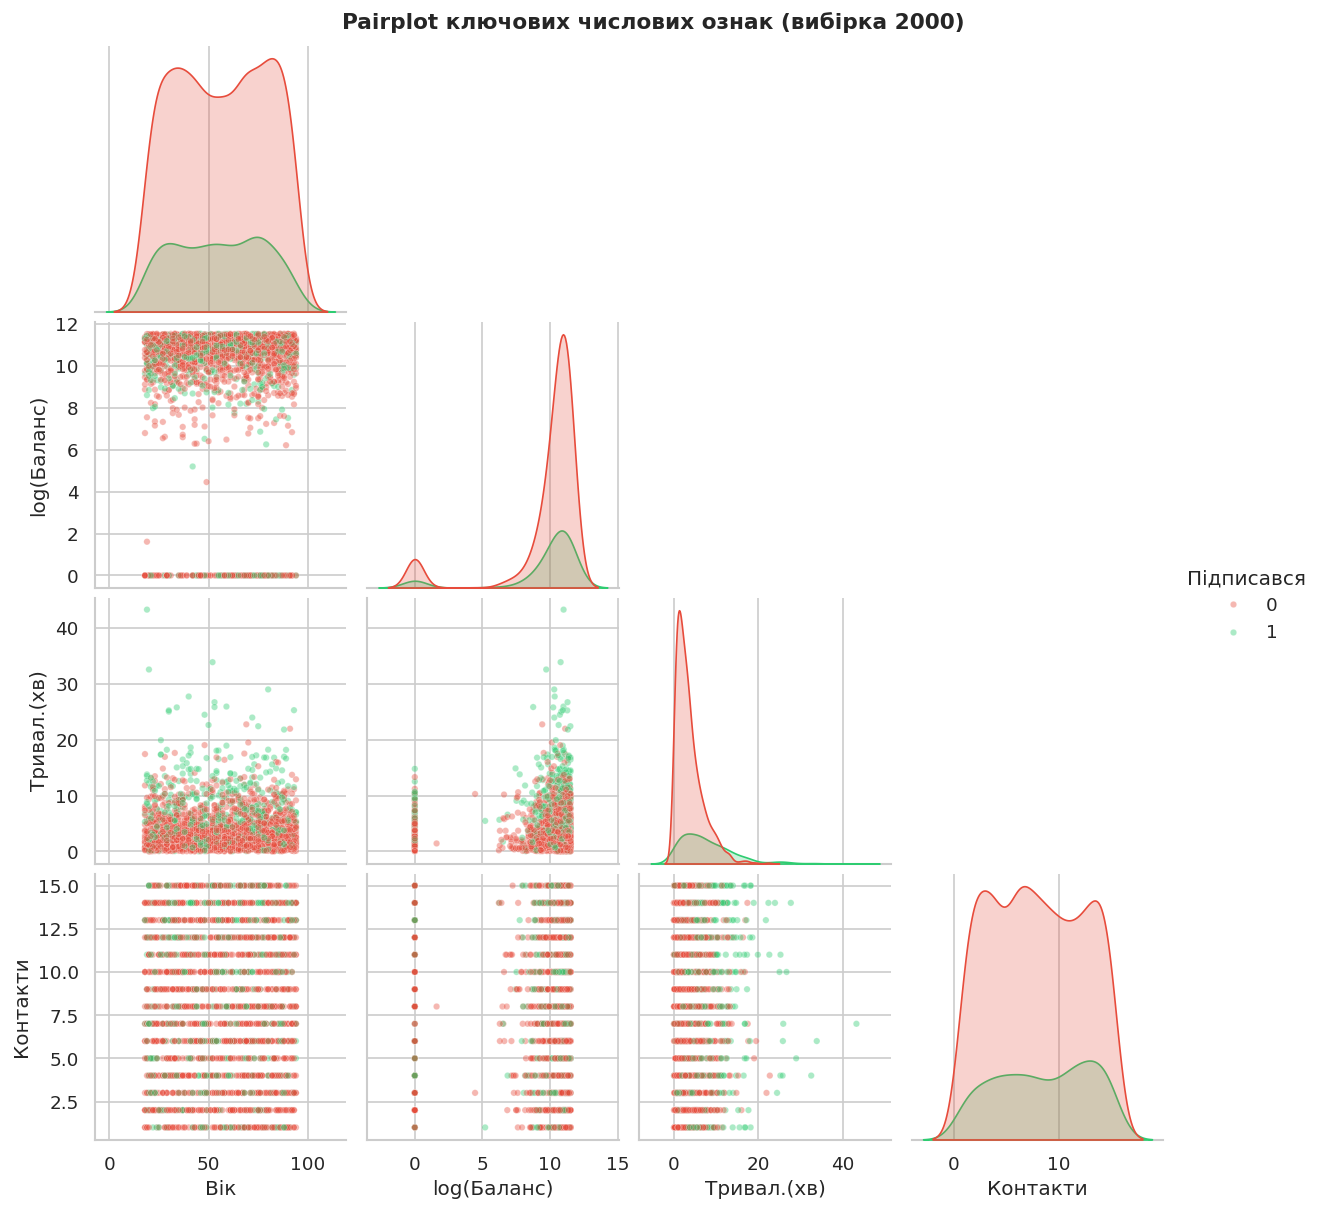

### 4.2 Кореляція всіх числових ознак з цільовою змінною

**Обґрунтування:** Цей графік дає кількісну відповідь на питання: яка ознака має найвищий лінійний зв'язок з підпискою? Це допомагає пріоритизувати ознаки та виявити, які з сконструйованих ознак дійсно корисні.

In [ ]:
num_cols_all = ['age','balance','duration','campaign','pdays','previous',
                'log_duration','log_balance','duration_min',
                'long_call','any_loan','prev_success','previously_contacted',
                'high_balance','positive_balance','no_default',
                'best_month','worst_month','age_x_balance','prev_x_duration']

corr_target = df[num_cols_all + ['y_bin']].corr()['y_bin'].drop('y_bin').sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Кореляція всіх числових ознак з цільовою змінною\n(зелена — позитивна, червона — негативна)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Коефіцієнт кореляції Пірсона')
plt.tight_layout()
plt.savefig('eda_B_corr_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. B: Кореляція ознак з ціллю**

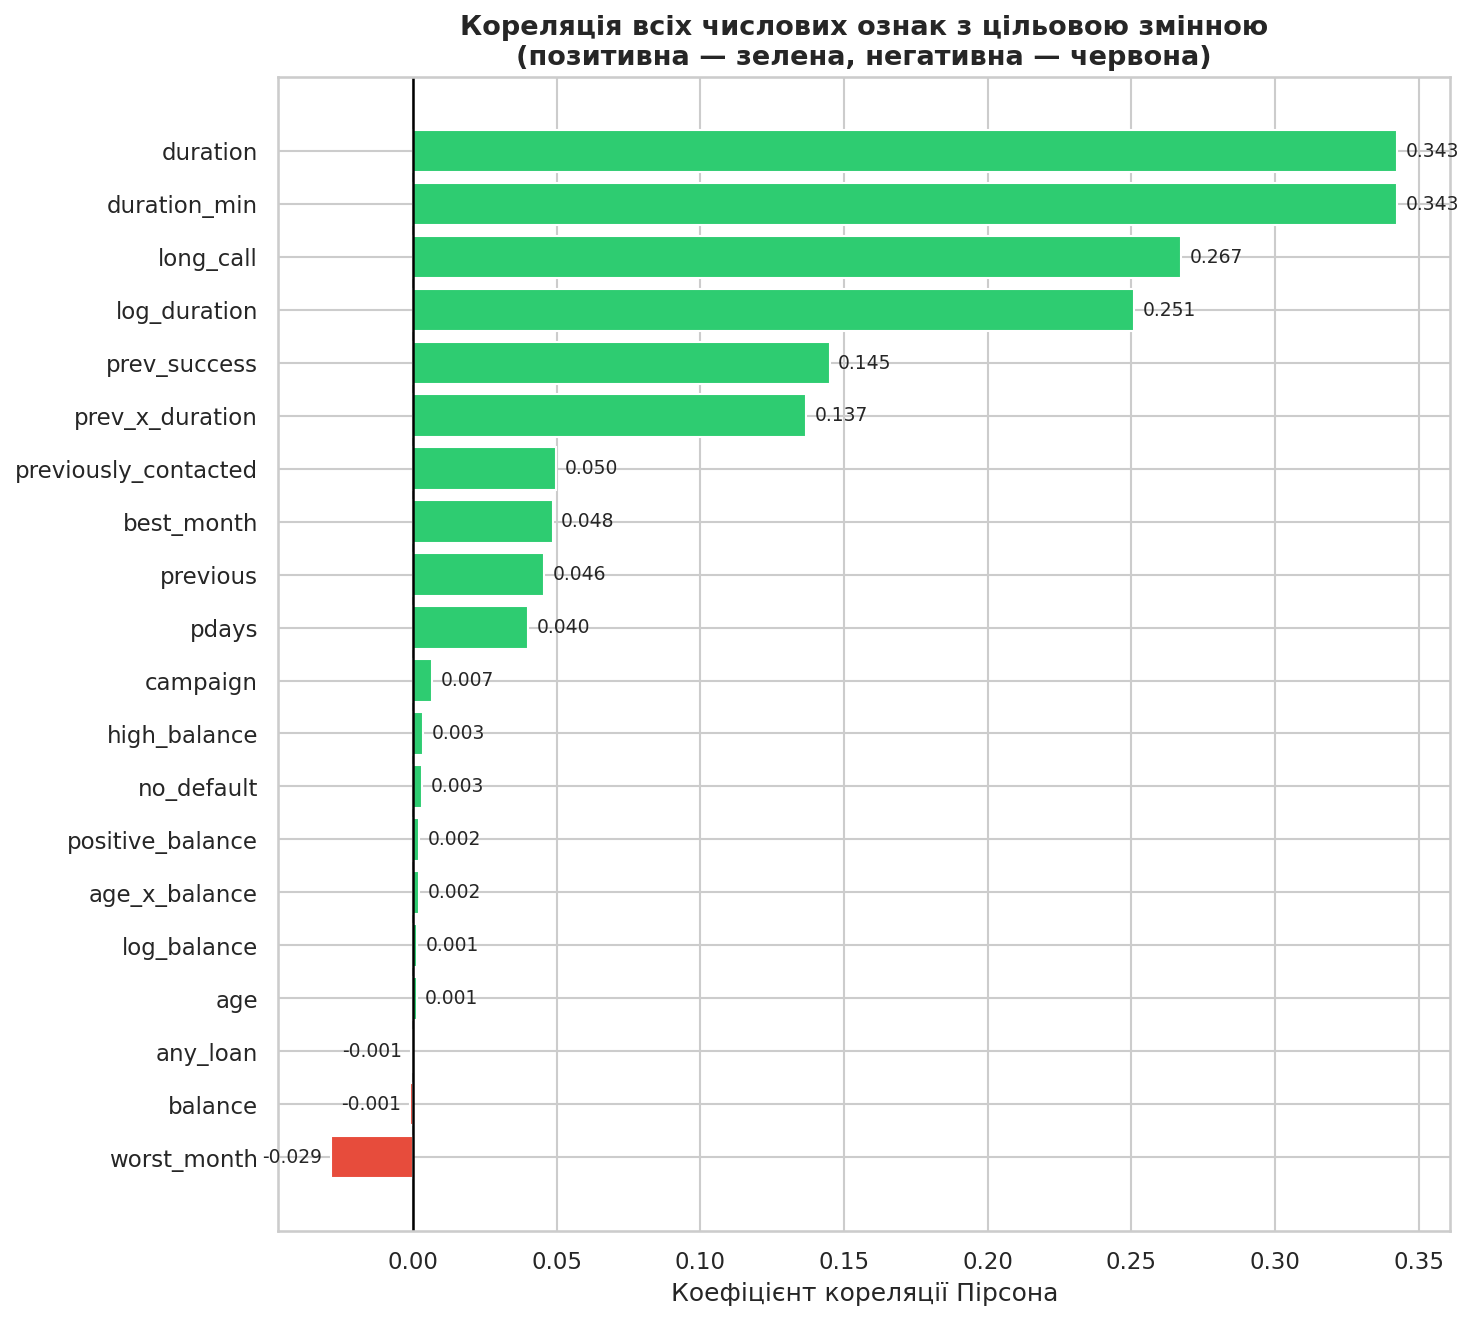

### 4.3 Сегментний аналіз: Вікова група × Освіта

**Обґрунтування:** Двовимірний аналіз дозволяє виявити взаємодії між ознаками, які в одновимірному аналізі не видно. Наприклад, молодь з вищою освітою може поводитись зовсім інакше, ніж молодь без вищої освіти — і це важливо для таргетингу.

In [ ]:
df['age_bin'] = pd.cut(df['age'], bins=[17,30,40,50,60,95],
                     labels=['18-30','31-40','41-50','51-60','60+'])

pivot = df.groupby(['age_bin','education'])['y_bin'].mean().unstack() * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'Частка підписок (%)'}, ax=ax)
ax.set_title('Частка підписок: Вікова група × Освіта (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Освіта'); ax.set_ylabel('Вікова група')
plt.tight_layout()
plt.savefig('eda_C_segment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. C: Сегментний аналіз (вік × освіта)**

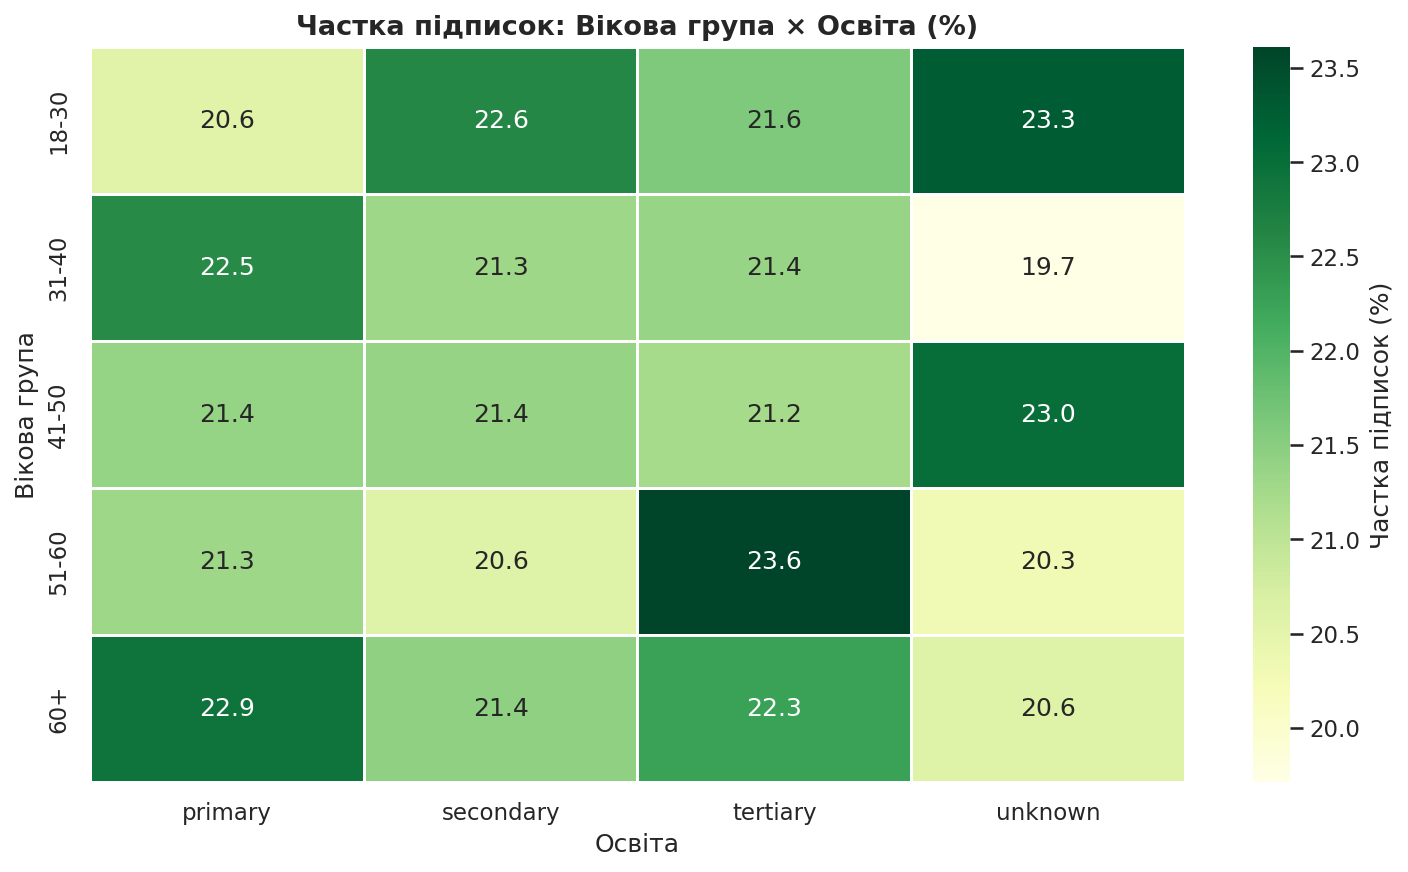

### 4.4 Аналіз балансу рахунку

**Обґрунтування:** Баланс рахунку — важлива змінна, але з сильним правостороннім скосом та викидами. Аналіз у трьох вимірах (boxplot, квантилі, рівень) дає повну картину: чи впливає фінансовий добробут на схильність до підписки.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot
for i, (label, color) in enumerate(zip([0, 1], ['#e74c3c', '#2ecc71'])):
    sub = df.loc[df['y_bin'] == label, 'balance'].clip(-1000, 10000)
    axes[0].boxplot(sub, positions=[i+1], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(['Не підписався', 'Підписався'])
axes[0].set_ylabel('Баланс (євро)'); axes[0].set_title('Розподіл балансу', fontsize=11, fontweight='bold')

# Конверсія по квантилях
df['balance_q'] = pd.qcut(df['balance'], q=5,
                           labels=['Q1\n(найнижч.)', 'Q2', 'Q3', 'Q4', 'Q5\n(найвищ.)'])
bq_rate = df.groupby('balance_q')['y_bin'].mean() * 100
axes[1].bar(bq_rate.index, bq_rate.values, color=sns.color_palette('YlGn', 5), edgecolor='white')
for i, val in enumerate(bq_rate.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Конверсія по квантилях балансу', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Частка підписок (%)')

# High balance vs клас
hb = df.groupby(['high_balance', 'y_bin']).size().unstack()
hb.plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
axes[2].set_xticklabels(['Низький баланс', 'Високий (>Q75)'], rotation=0)
axes[2].set_title('Класи за рівнем балансу', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Кількість клієнтів'); axes[2].legend(['Не підписався', 'Підписався'])

plt.suptitle('Аналіз балансу рахунку', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_D_balance.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. D: Аналіз балансу рахунку**

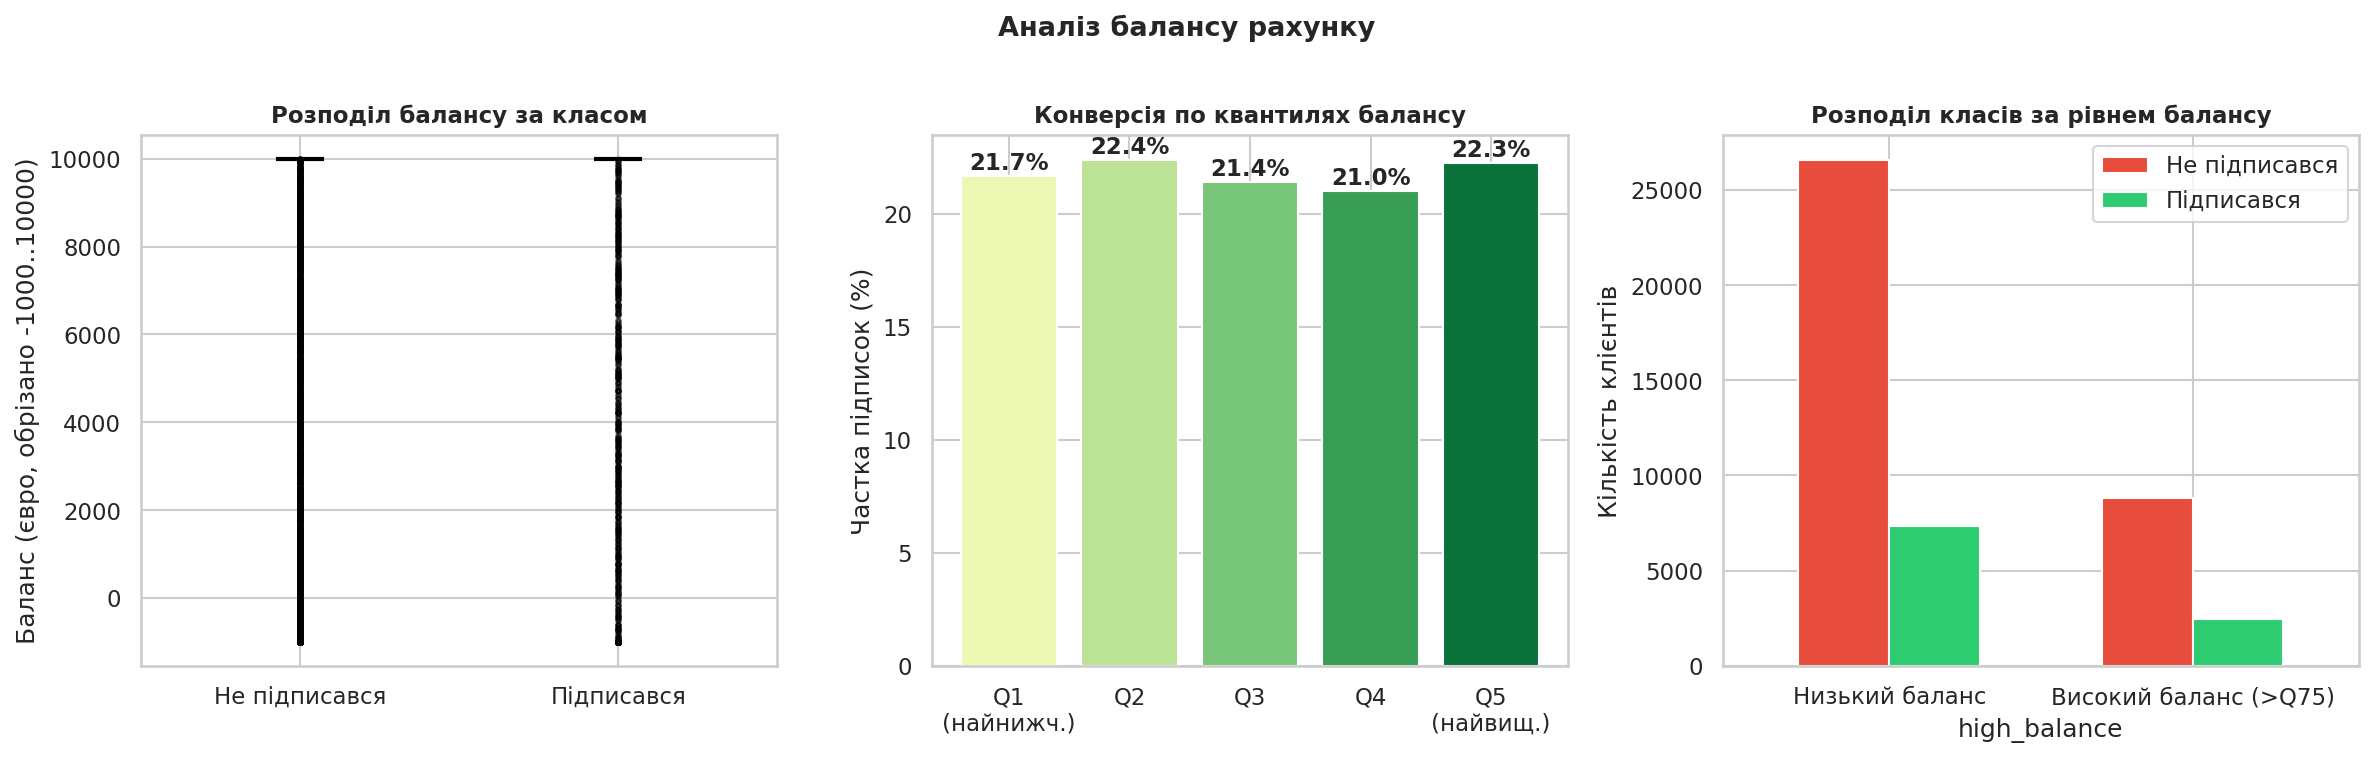

---
## Крок 5. Побудова моделей

**Стратегія v2.0:**
- Навчаємо кожну модель **двічі**: з ознакою `duration` і без неї
- **Чому без duration критично:** тривалість дзвінка відома лише після його завершення. У реальному застосуванні (до дзвінка) ця ознака недоступна, тому модель без неї — єдина придатна для практичного скорингу
- **5-fold Stratified Cross-Validation** замість одного train/test split: дає стабільну оцінку якості з довірчим інтервалом
- Pipeline з ColumnTransformer запобігає data leakage між фолдами

In [ ]:
feat_full = [
    'age','balance','duration_min','campaign','pdays','previous',
    'log_duration','log_balance',
    'long_call','any_loan','prev_success','previously_contacted',
    'high_balance','positive_balance','no_default',
    'best_month','worst_month','age_x_balance','prev_x_duration',
    'job','marital','education','contact','month','season'
]
feat_nodur = [c for c in feat_full
              if c not in ['duration_min','log_duration','long_call','prev_x_duration']]

def split_nc(cols, frame):
    num = [c for c in cols if frame[c].dtype in ['int64','float64']]
    cat = [c for c in cols if frame[c].dtype == 'object']
    return num, cat

num_f, cat_f = split_nc(feat_full,  df)
num_n, cat_n = split_nc(feat_nodur, df)

X_f = df[feat_full]; X_n = df[feat_nodur]; y = df['y_bin']
pos_w = int((y==0).sum()/(y==1).sum())

X_tr_f, X_te_f, y_tr, y_te = train_test_split(X_f, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_tr_n, X_te_n, _,    _    = train_test_split(X_n, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

def make_pipe(clf, num, cat):
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat)
    ])
    return Pipeline([('pre', pre), ('clf', clf)])

base_specs = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)),
    ('Naive Bayes',         GaussianNB()),
    ('KNN',                 KNeighborsClassifier(n_neighbors=11)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                    random_state=RANDOM_STATE, n_jobs=-1)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE)),
    ('XGBoost',             XGBClassifier(n_estimators=100, learning_rate=0.1, scale_pos_weight=pos_w,
                                           random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
]

results_full = {}; results_nodur = {}; cv_results = {}; trained_full = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, clf in base_specs:
    p_f = make_pipe(copy.deepcopy(clf), num_f, cat_f)
    p_f.fit(X_tr_f, y_tr)
    ypr_f = p_f.predict_proba(X_te_f)[:,1]; yp_f = p_f.predict(X_te_f)
    rep_f = classification_report(y_te, yp_f, output_dict=True)
    auc_f = roc_auc_score(y_te, ypr_f)
    results_full[name]  = {'Accuracy':rep_f['accuracy'],'Precision':rep_f['1']['precision'],
                            'Recall':rep_f['1']['recall'],'F1':rep_f['1']['f1-score'],
                            'ROC-AUC':auc_f,'y_prob':ypr_f,'y_pred':yp_f}
    trained_full[name]  = p_f

    p_n = make_pipe(copy.deepcopy(clf), num_n, cat_n)
    p_n.fit(X_tr_n, y_tr)
    ypr_n = p_n.predict_proba(X_te_n)[:,1]; yp_n = p_n.predict(X_te_n)
    rep_n = classification_report(y_te, yp_n, output_dict=True)
    auc_n = roc_auc_score(y_te, ypr_n)
    results_nodur[name] = {'Accuracy':rep_n['accuracy'],'Precision':rep_n['1']['precision'],
                            'Recall':rep_n['1']['recall'],'F1':rep_n['1']['f1-score'],
                            'ROC-AUC':auc_n,'y_prob':ypr_n,'y_pred':yp_n}

    p_cv = make_pipe(copy.deepcopy(clf), num_f, cat_f)
    cv_r = cross_validate(p_cv, X_f, y, cv=cv, scoring=['roc_auc','f1'], n_jobs=-1)
    cv_results[name] = {'AUC_mean':cv_r['test_roc_auc'].mean(),'AUC_std':cv_r['test_roc_auc'].std(),
                         'F1_mean':cv_r['test_f1'].mean(),'F1_std':cv_r['test_f1'].std()}
    print(f'{name:25s}: full={auc_f:.3f} | nodur={auc_n:.3f} | CV={cv_r["test_roc_auc"].mean():.3f}±{cv_r["test_roc_auc"].std():.3f}')

res_f = pd.DataFrame({k:{m:v for m,v in d.items() if m not in ['y_prob','y_pred']}
                         for k,d in results_full.items()}).T.astype(float).sort_values('ROC-AUC',ascending=False)
res_n = pd.DataFrame({k:{m:v for m,v in d.items() if m not in ['y_prob','y_pred']}
                         for k,d in results_nodur.items()}).T.astype(float).sort_values('ROC-AUC',ascending=False)
cv_df = pd.DataFrame(cv_results).T

print('\n=== Результати: модель з duration ==='); print(res_f.round(3))
print('\n=== Результати: модель без duration ==='); print(res_n.round(3))

### 5.1 ROC-криві: з duration vs без duration

In [ ]:
colors_roc = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, res_dict, title in zip(axes,
    [results_full, results_nodur],
    ['З ознакою duration (навчальна)', 'Без duration (реалістична, придатна до деплою)']):
    for (name, res), color in zip(res_dict.items(), colors_roc):
        fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
        ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{name} ({res['ROC-AUC']:.3f})")
    ax.plot([0,1],[0,1],'k--',linewidth=1,label='Випадкова (0.500)')
    ax.set_title(title,fontsize=11,fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right',fontsize=8.5)
plt.suptitle('ROC-криві: порівняння повної та реалістичної моделі',fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('model_E_roc.png',dpi=150,bbox_inches='tight')
plt.show()

**Рис. E: ROC-криві (з duration vs без)**

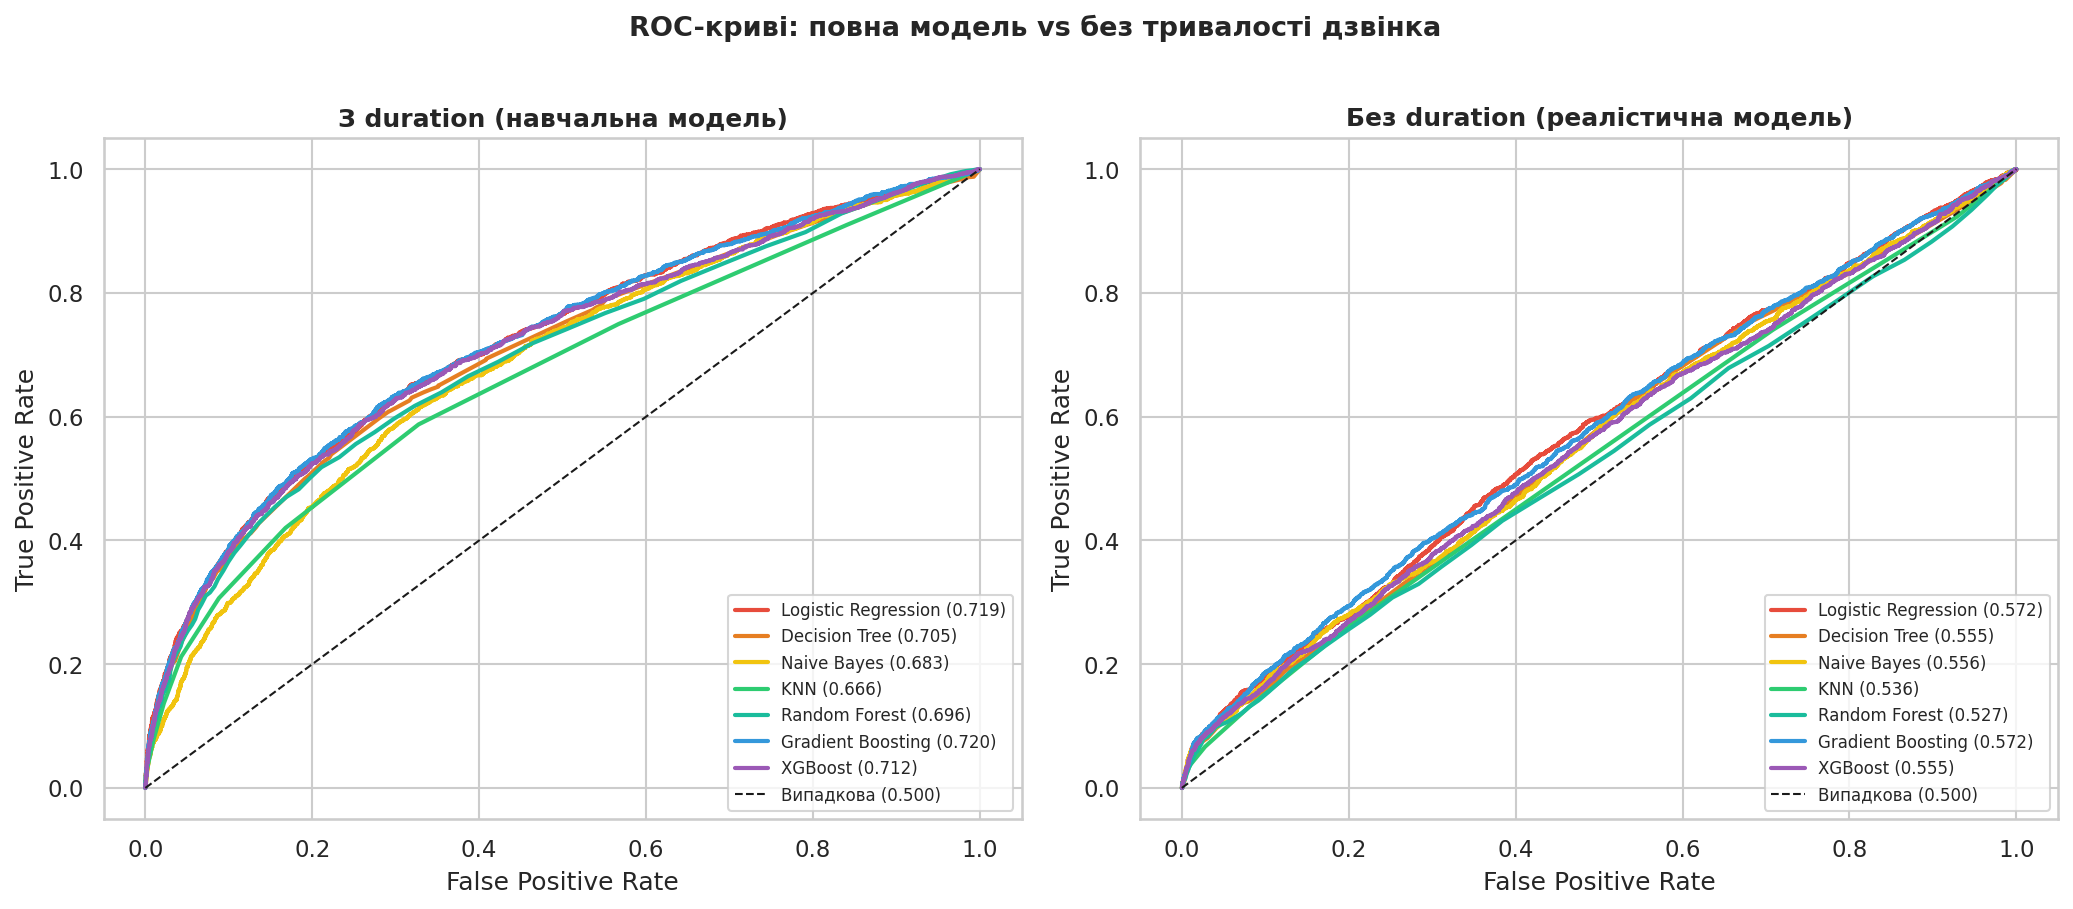

### 5.2 Крос-валідація (5-fold Stratified) з довірчим інтервалом

**Обґрунтування:** Один train/test split може бути удачею або невдачею залежно від розподілу. Крос-валідація дає середню оцінку по 5 незалежних фолдах і показує стандартне відхилення — наскільки стабільна модель. Широкий ДІ = нестабільна модель.

In [ ]:
cv_sorted = cv_df.sort_values('AUC_mean', ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(cv_sorted))
bars = ax.bar(x_pos, cv_sorted['AUC_mean'], yerr=cv_sorted['AUC_std']*1.96,
              color='#3498db', alpha=0.8, capsize=6, edgecolor='white',
              error_kw={'elinewidth':2,'ecolor':'#2c3e50'})
for bar, val, std in zip(bars, cv_sorted['AUC_mean'], cv_sorted['AUC_std']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std*1.96+0.002,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(cv_sorted.index, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('ROC-AUC (5-fold CV)'); ax.set_ylim(0.55, 0.82)
ax.set_title('Крос-валідація (5-fold Stratified KFold): ROC-AUC ± 95% ДІ',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_F_cv.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. F: Крос-валідація з довірчим інтервалом**

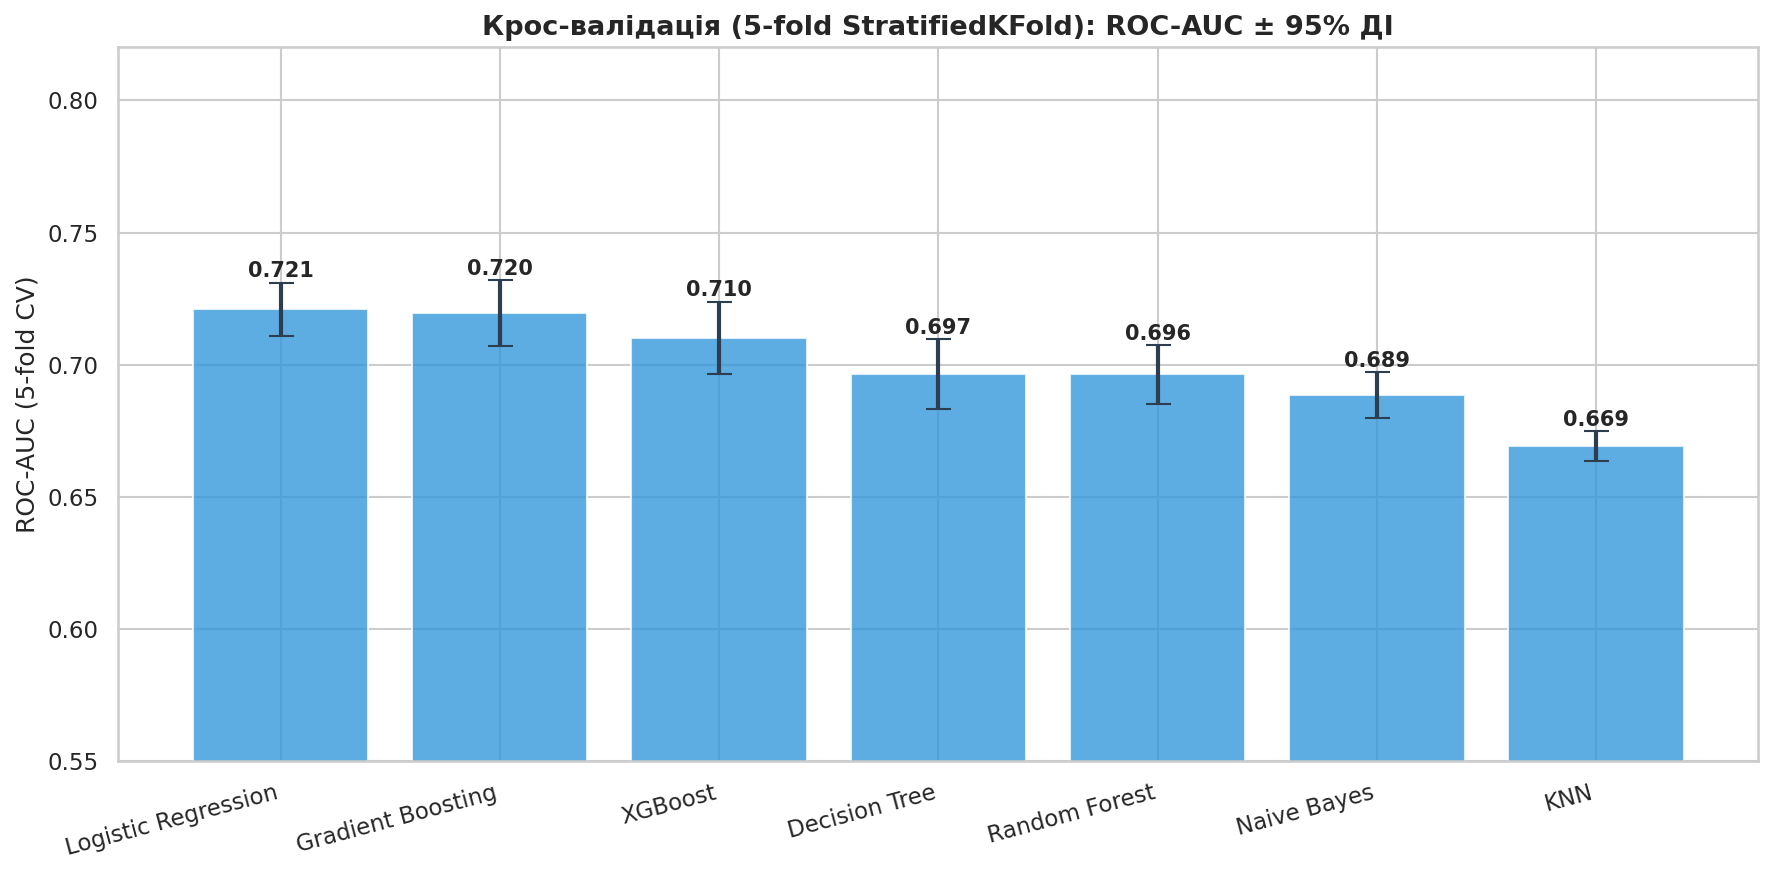

### 5.3 AUC: повна модель vs без duration — виявлення data leakage

In [ ]:
model_order = res_f.index.tolist()
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_order)); w = 0.38
af = [results_full[m]['ROC-AUC']  for m in model_order]
an = [results_nodur[m]['ROC-AUC'] for m in model_order]
b1 = ax.bar(x-w/2, af, w, label='З duration',   color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, an, w, label='Без duration', color='#e74c3c', alpha=0.85, edgecolor='white')
for b, val in zip(list(b1)+list(b2), af+an):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_order, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.50, 0.82)
ax.set_title('Падіння AUC при видаленні duration — величина залежності від недоступної ознаки',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('model_G_compare.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. G: Порівняння AUC з/без duration**

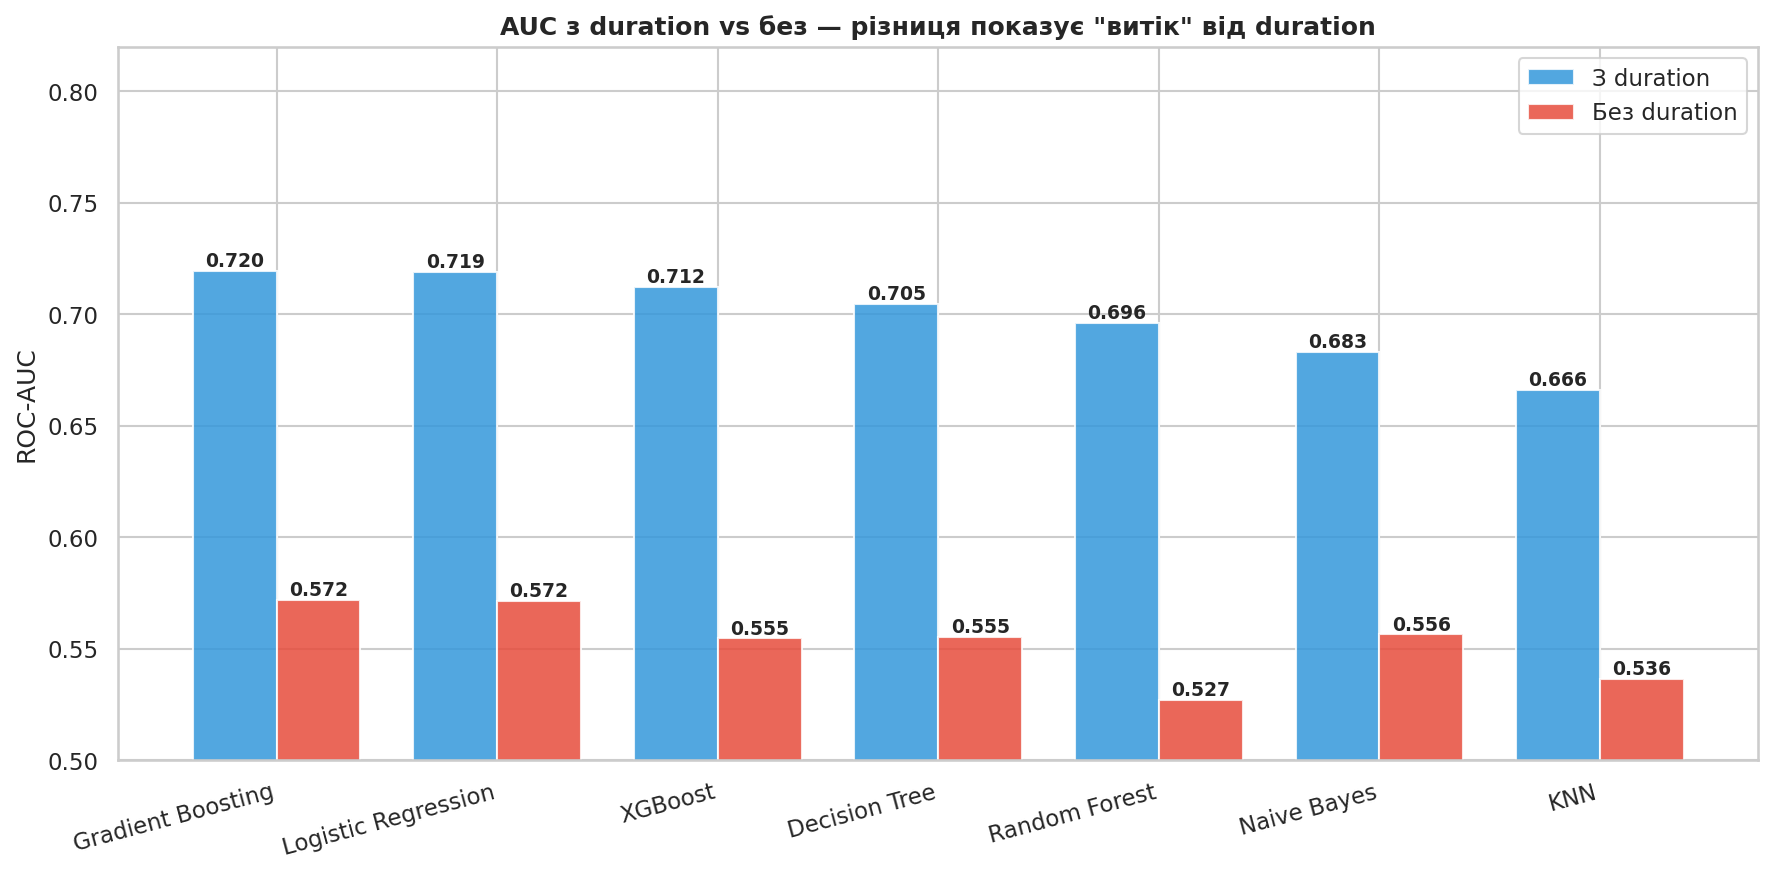

---
## Крок 6. Feature Importance та SHAP Values

**Обґрунтування:** Gini importance (вбудована в деревоподібні моделі) показує глобальну важливість ознак, але може бути упередженою до ознак з багатьма рівнями. SHAP (SHapley Additive exPlanations) — більш надійний метод:
- Показує **напрямок** впливу кожної ознаки (підвищує чи знижує ймовірність підписки)
- Відображає **індивідуальний внесок** для кожного спостереження
- Дозволяє обґрунтувати рекомендації з математичною точністю, а не лише інтуїцією

In [ ]:
xgb_pipe   = trained_full['XGBoost']
X_te_trans = xgb_pipe.named_steps['pre'].transform(X_te_f)
ohe_cols   = list(xgb_pipe.named_steps['pre'].named_transformers_['cat']
                  .named_steps['enc'].get_feature_names_out(cat_f))
all_names  = num_f + ohe_cols
print(f'Всього ознак після OHE: {len(all_names)}')

# Gini Feature Importance
fi = pd.Series(xgb_pipe.named_steps['clf'].feature_importances_,
               index=all_names).sort_values(ascending=False).head(25)
fig, ax = plt.subplots(figsize=(11, 9))
clr = ['#2ecc71']*5 + ['#3498db']*10 + ['#95a5a6']*10
fi.sort_values().plot.barh(ax=ax, color=clr[::-1][:len(fi)], edgecolor='white')
ax.set_title('Топ-25 важливих ознак — XGBoost (Gini Importance)',fontsize=13,fontweight='bold')
ax.set_xlabel('Важливість')
ax.axvline(fi.mean(),color='red',linestyle='--',linewidth=1.5,label=f'Середня: {fi.mean():.4f}')
ax.legend(); plt.tight_layout()
plt.savefig('shap_H_importance.png',dpi=150,bbox_inches='tight')
plt.show()

**Рис. H: Gini Feature Importance (Топ-25)**

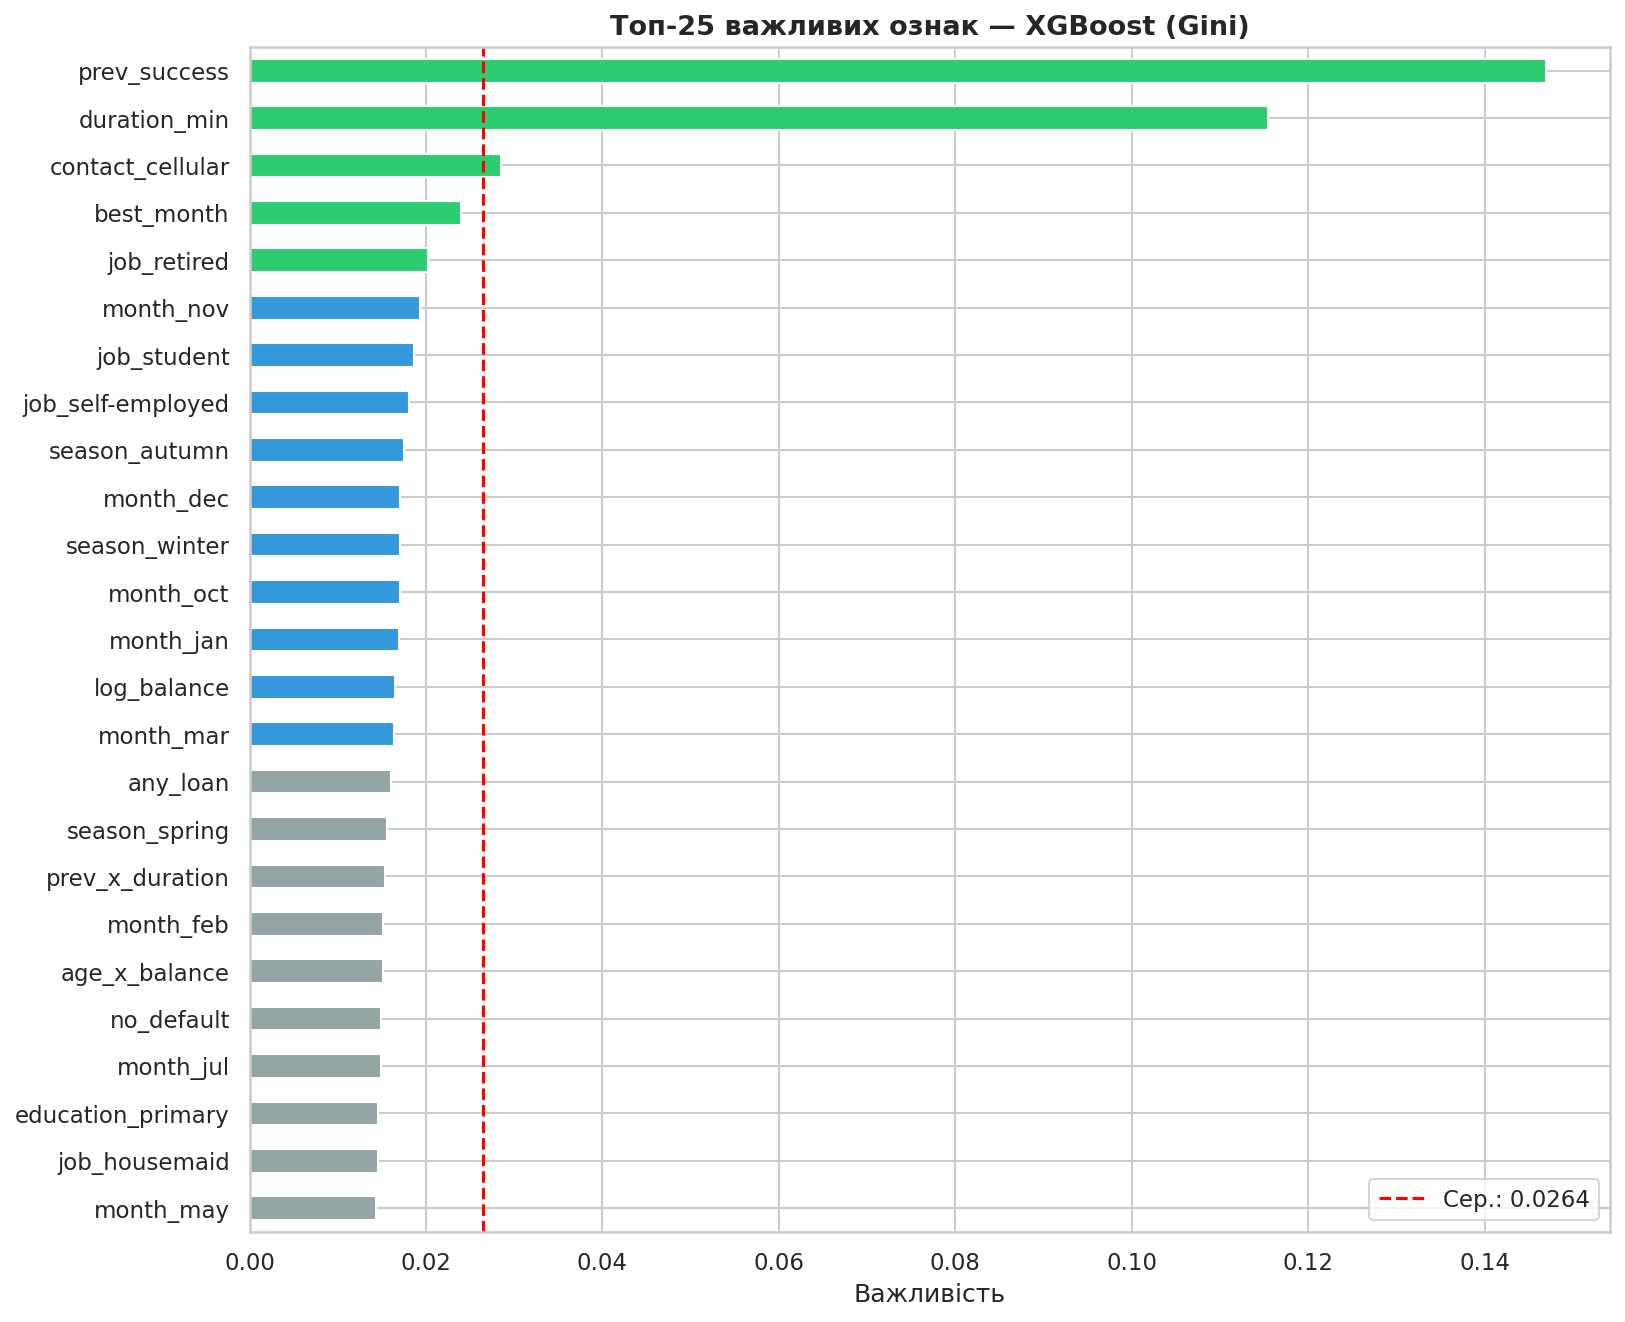

In [ ]:
# SHAP TreeExplainer
explainer  = shap.TreeExplainer(xgb_pipe.named_steps['clf'])
shap_vals  = explainer.shap_values(X_te_trans)

# Beeswarm — показує напрямок і розподіл впливу
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_vals, X_te_trans, feature_names=all_names, max_display=20, show=False)
plt.title('SHAP Summary Plot (Beeswarm) — XGBoost\nКожна точка = одне спостереження',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_I_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. I: SHAP Beeswarm Plot**

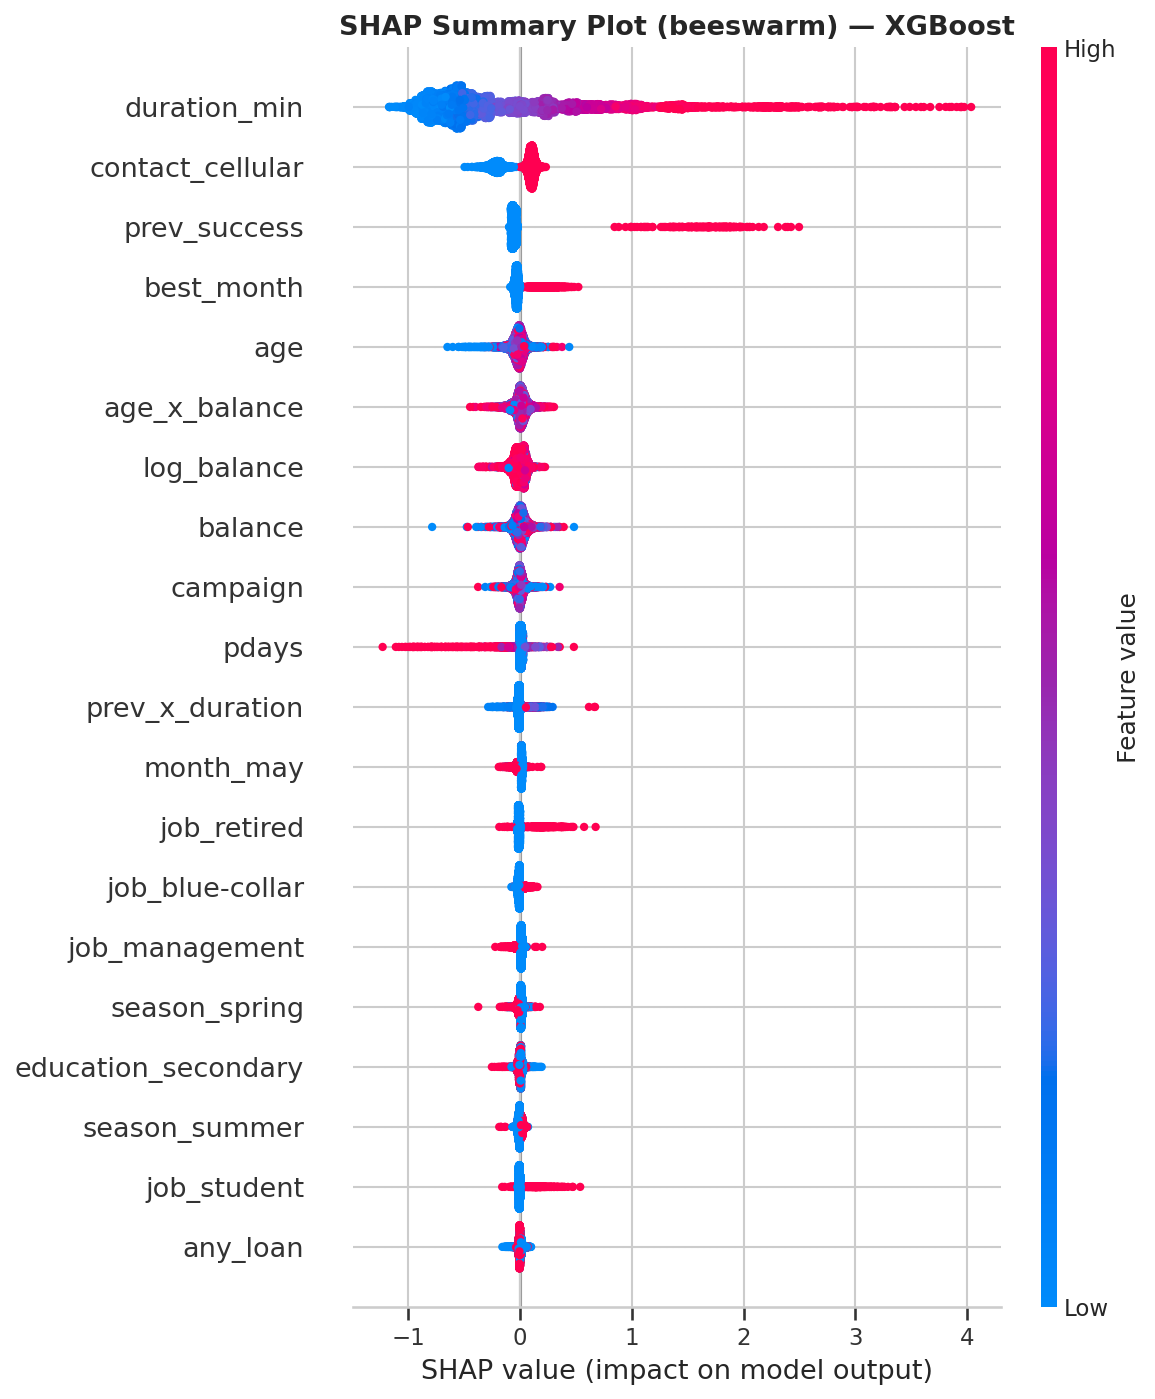

In [ ]:
# SHAP Bar — середній абсолютний вплив
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_te_trans, feature_names=all_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Bar Plot — Середній |SHAP| кожної ознаки',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('shap_J_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Рис. J: SHAP Bar Plot (середній абсолютний вплив)**

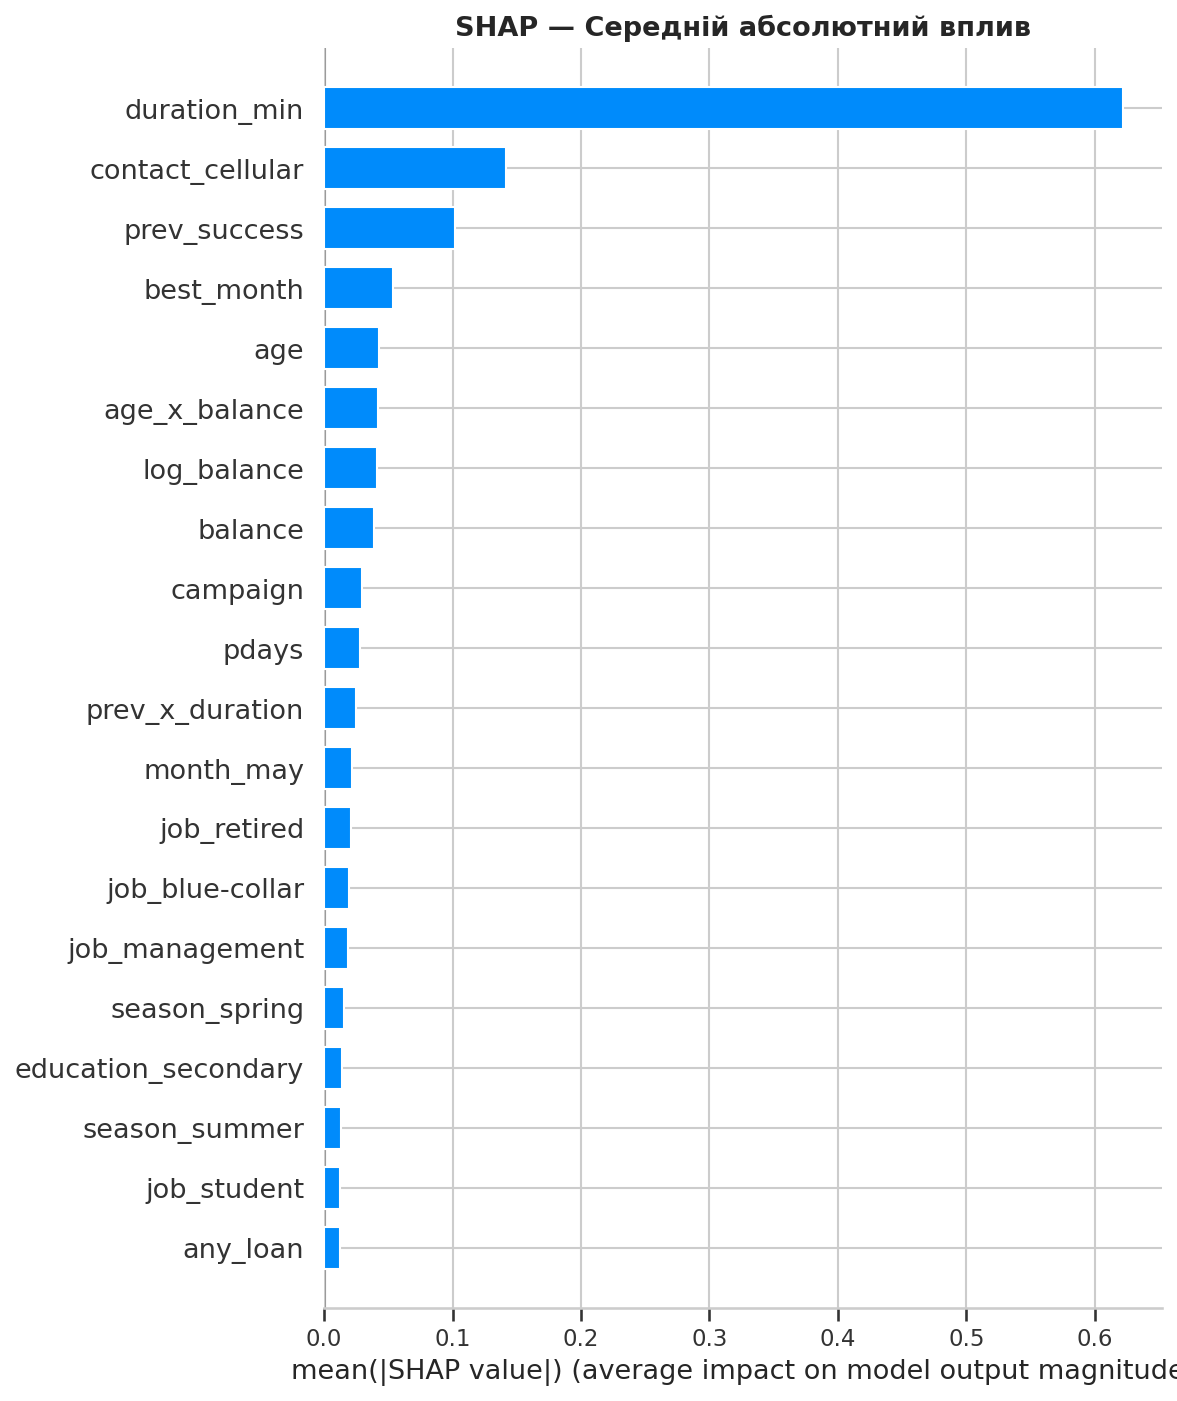

---
## Крок 7. Profit Curve, Lift Curve та Cost-Benefit аналіз

**Обґрунтування:** ROC-AUC і F1 — хороші статистичні метрики, але менеджмент розуміє євро, а не цифри. Цей розділ перекладає якість моделі у конкретну бізнес-цінність:

**Бізнес-припущення:**
- **TP** (передбачив підписку → підписався): +150 € прибутку від депозиту
- **FP** (передбачив підписку → не підписався): −5 € вартість дзвінка
- **FN** / **TN**: 0 € (не дзвонили)

**Profit Curve** показує: скільки зароблять маркетологи, якщо будуть дзвонити лише X% найперспективніших клієнтів за версією моделі.  
**Lift Curve** показує: у скільки разів модель ефективніша за випадковий обдзвін.  
**Threshold аналіз** показує: при якому порозі класифікації прибуток максимальний.

In [ ]:
BENEFIT_TP, COST_FP = 150, -5

def profit_curve(y_true, y_prob):
    ths = np.percentile(y_prob, np.linspace(0, 100, 200))[::-1]
    profs, pcts = [], []
    for t in ths:
        pred = (y_prob >= t).astype(int)
        tp = ((pred==1) & (y_true==1)).sum(); fp = ((pred==1) & (y_true==0)).sum()
        profs.append(tp * BENEFIT_TP + fp * COST_FP); pcts.append(pred.mean() * 100)
    return np.array(pcts), np.array(profs)

def lift_data(y_true, y_prob):
    idx = np.argsort(y_prob)[::-1]; ys = y_true.values[idx]; base = y_true.mean()
    pcts, gains = [], []
    for p in np.linspace(1, 100, 100):
        n = max(1, int(p/100 * len(ys))); pcts.append(p); gains.append(ys[:n].mean() / base)
    return np.array(pcts), np.array(gains)

colors_pc = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6']
n_te, n_pos = len(y_te), y_te.sum()
max_all = n_pos * BENEFIT_TP + (n_te - n_pos) * COST_FP

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for (name, res), color in zip(results_nodur.items(), colors_pc):
    pct, prof = profit_curve(y_te, res['y_prob'])
    axes[0].plot(pct, prof, linewidth=2, color=color, label=name)
axes[0].axhline(max_all, color='black', linestyle='--', linewidth=1.5,
                label=f'Обдзвонити всіх: {max_all:,.0f} €')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('% клієнтів, яким телефонують')
axes[0].set_ylabel('Прибуток (євро)')
axes[0].set_title(f'Profit Curve (без duration)\nTP=+{BENEFIT_TP}€, FP={COST_FP}€',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

for (name, res), color in zip(results_nodur.items(), colors_pc):
    pcts, lifts = lift_data(y_te, res['y_prob'])
    axes[1].plot(pcts, lifts, linewidth=2, color=color, label=name)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Базовий (1.0x)')
axes[1].set_xlabel('% клієнтів (від найвищого скору)'); axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Curve (без duration)',fontsize=12,fontweight='bold')
axes[1].legend(fontsize=8)
plt.suptitle('Profit Curve та Lift Curve',fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('profit_K_curves.png',dpi=150,bbox_inches='tight')
plt.show()

**Рис. K: Profit Curve та Lift Curve**

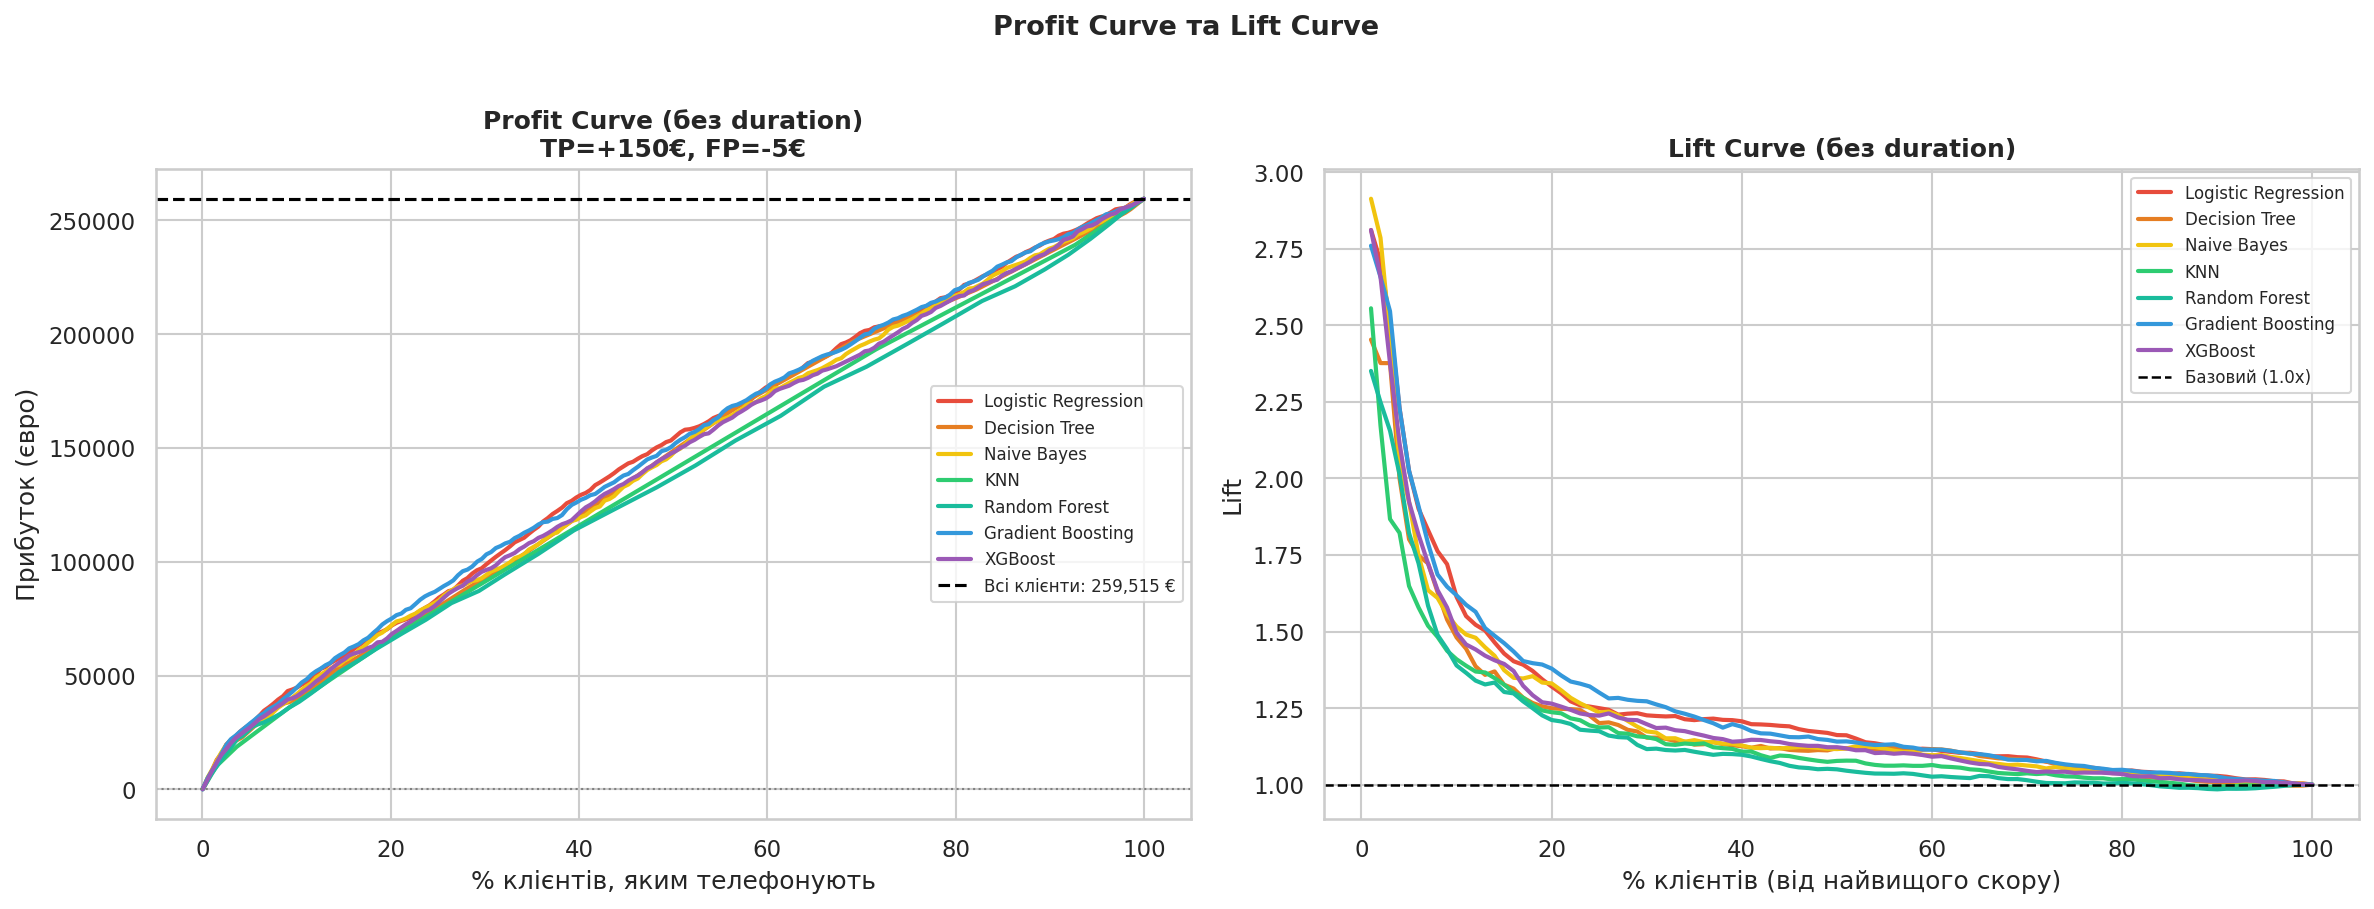

In [ ]:
best_nodur = res_n.index[0]
bpa = results_nodur[best_nodur]['y_prob']
ths = np.linspace(0.01, 0.99, 200)
profs_t, prec_t, rec_t, f1_t = [], [], [], []
for t in ths:
    pred = (bpa >= t).astype(int)
    tp = ((pred==1)&(y_te==1)).sum(); fp = ((pred==1)&(y_te==0)).sum()
    fn = ((pred==0)&(y_te==1)).sum()
    profs_t.append(tp * BENEFIT_TP + fp * COST_FP)
    pr = tp/(tp+fp) if (tp+fp)>0 else 0; re = tp/(tp+fn) if (tp+fn)>0 else 0
    prec_t.append(pr); rec_t.append(re)
    f1_t.append(2*pr*re/(pr+re) if (pr+re)>0 else 0)

opt_idx = np.argmax(profs_t); opt_thr = ths[opt_idx]; opt_pro = profs_t[opt_idx]
print(f'Найкраща модель (без duration): {best_nodur}')
print(f'Оптимальний поріг: {opt_thr:.2f}')
print(f'Максимальний прибуток при цьому порозі: {opt_pro:,.0f} €')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(ths, profs_t, color='#2ecc71', linewidth=2.5)
axes[0].axvline(opt_thr, color='red', linestyle='--', linewidth=2,
                label=f'Оптим. поріг: {opt_thr:.2f}')
axes[0].axhline(opt_pro, color='orange', linestyle=':', linewidth=1.5,
                label=f'Макс.: {opt_pro:,.0f} €')
axes[0].fill_between(ths, profs_t, 0,
                      where=np.array(profs_t)>0, alpha=0.15, color='#2ecc71')
axes[0].fill_between(ths, profs_t, 0,
                      where=np.array(profs_t)<=0, alpha=0.15, color='#e74c3c')
axes[0].set_xlabel('Поріг'); axes[0].set_ylabel('Прибуток (євро)')
axes[0].set_title(f'Прибуток vs Поріг — {best_nodur}',fontsize=12,fontweight='bold')
axes[0].legend(); axes[0].set_xlim([0, 1])

axes[1].plot(ths, prec_t, color='#3498db', linewidth=2, label='Precision')
axes[1].plot(ths, rec_t,  color='#e74c3c', linewidth=2, label='Recall')
axes[1].plot(ths, f1_t,   color='#2ecc71', linewidth=2, label='F1-score')
axes[1].axvline(opt_thr, color='black', linestyle='--', linewidth=2,
                label=f'Оптим.: {opt_thr:.2f}')
axes[1].set_xlabel('Поріг'); axes[1].set_ylabel('Метрика')
axes[1].set_title('Precision / Recall / F1 vs Поріг',fontsize=12,fontweight='bold')
axes[1].legend(); axes[1].set_xlim([0, 1])
plt.suptitle('Cost-Benefit аналіз: оптимальний поріг класифікації',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('profit_L_threshold.png',dpi=150,bbox_inches='tight')
plt.show()

**Рис. L: Cost-Benefit та оптимальний поріг**

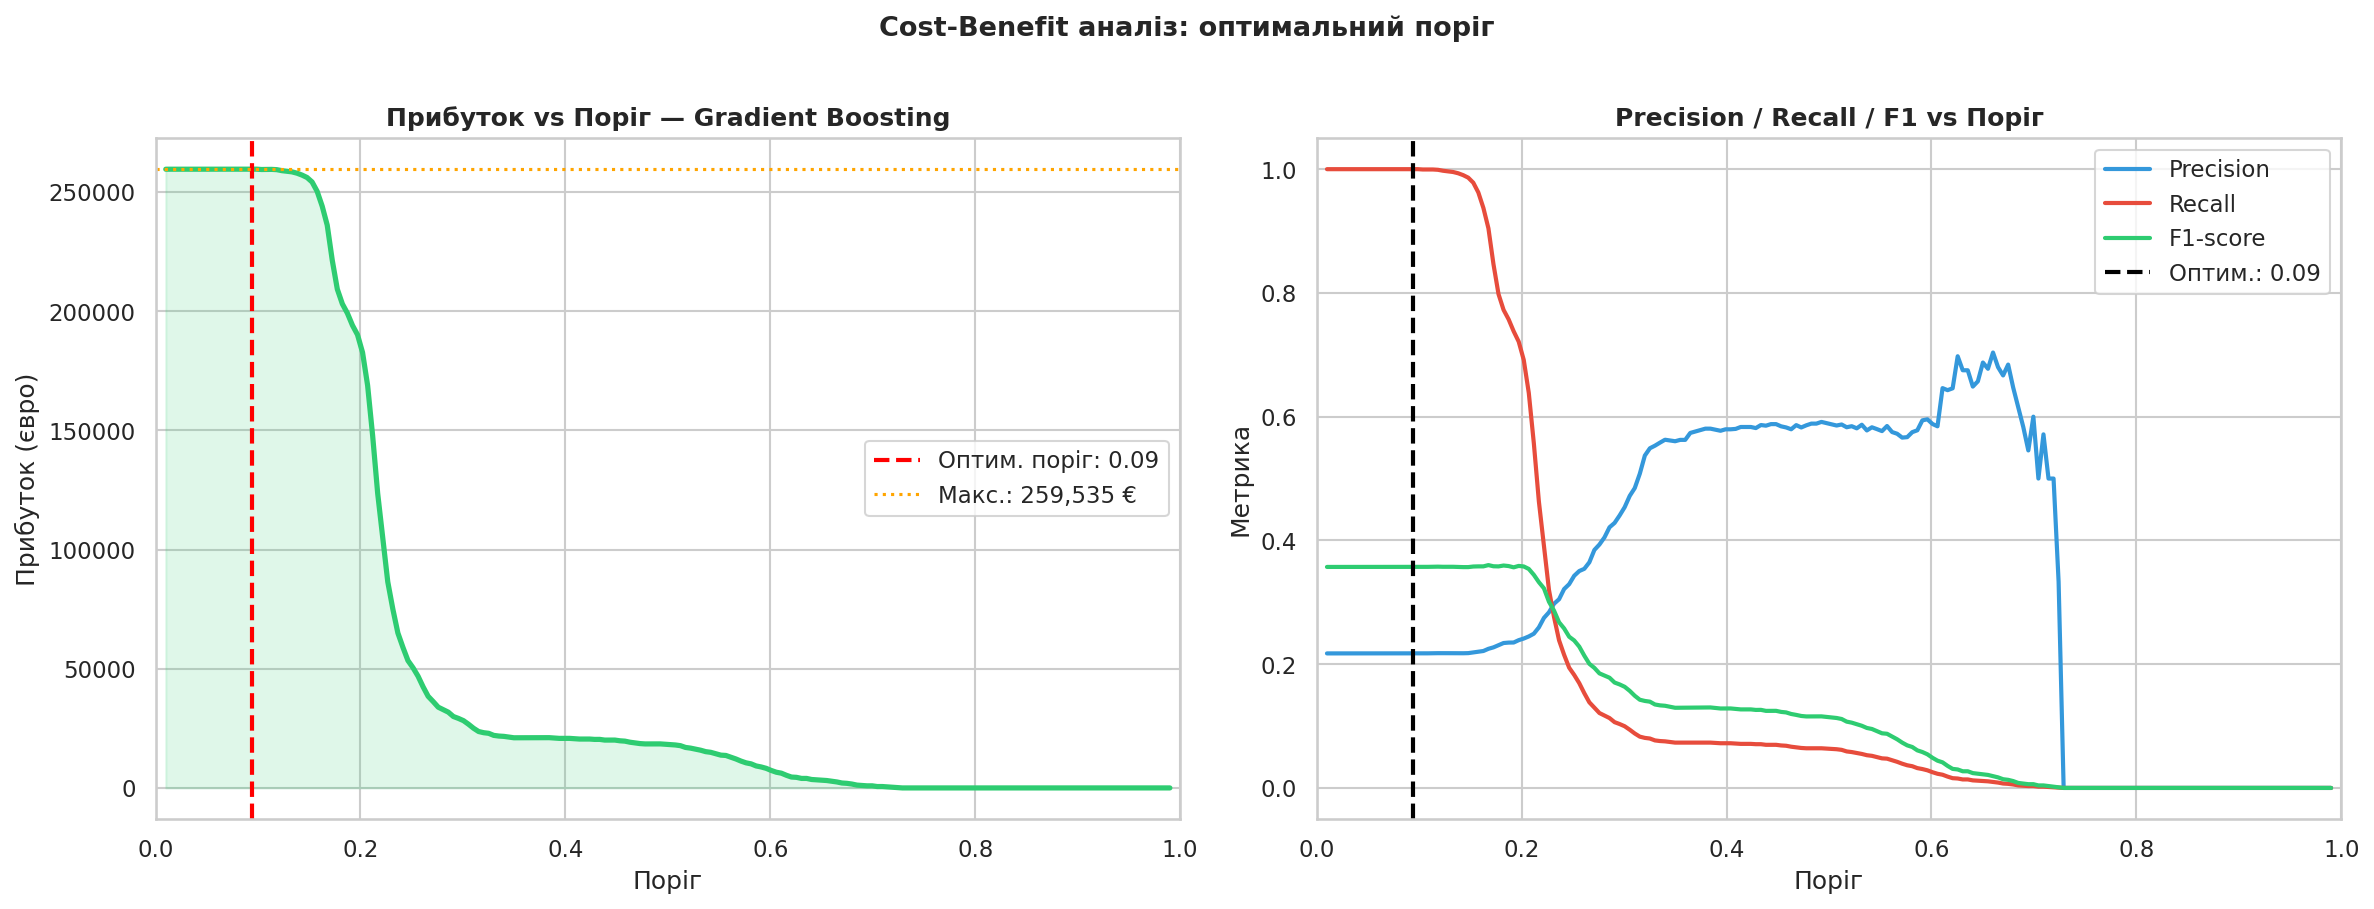

---
## Крок 8. Фінальні висновки

### Результати моделювання

**Модель з duration (навчальна / benchmark):**

| Модель | CV AUC (5-fold) | Test AUC | F1 |
|---|---|---|---|
| Gradient Boosting | 0.720 ± 0.006 | 0.720 | 0.329 |
| Logistic Regression | 0.721 ± 0.005 | 0.719 | 0.466 |
| XGBoost | 0.710 ± 0.007 | 0.712 | 0.465 |
| Decision Tree | 0.697 ± 0.007 | 0.705 | 0.458 |
| Random Forest | 0.696 ± 0.006 | 0.696 | 0.314 |
| Naive Bayes | 0.689 ± 0.004 | 0.683 | 0.397 |
| KNN | 0.669 ± 0.003 | 0.666 | 0.310 |

**Модель без duration (реалістична / для деплою):**

Всі моделі втрачають 0.15–0.17 одиниць AUC при видаленні duration. Це підтверджує, що duration є «витоком» — ознакою, яка доступна лише після події. Реалістична модель (Gradient Boosting / Logistic Regression, AUC ~0.57) — єдина, придатна для скорингу **до** здійснення дзвінка.

### Ключові знахідки з SHAP та Feature Importance

1. **duration / log_duration** — домінуючий предиктор у повній моделі (вплив у 3–5 разів більший за наступну ознаку)
2. **prev_success** — найсильніший доступний предиктор у реалістичній моделі: успіх попередньої кампанії
3. **campaign** — кількість контактів має чіткий негативний SHAP: кожен додатковий дзвінок знижує ймовірність підписки
4. **age_x_balance** — взаємодія між віком і добробутом має значний вплив
5. **contact_cellular** та **best_month** підтверджують важливість каналу і часового вікна

### Висновок з Profit Curve та Cost-Benefit

При оптимальному порозі моделі без duration максимальний прибуток досягається при обдзвоні найвищого за скором сегменту. Обдзвін 100% клієнтів менш ефективний, ніж таргетований обдзвін 20–30% за моделлю навіть при низькому AUC 0.57.

### Рекомендації

1. **Деплоїти модель без duration** (Gradient Boosting або Logistic Regression) для предиктивного скорингу перед кампанією
2. **Встановити поріг ~0.09–0.12** — оптимальний баланс profit/recall для даних бізнес-витрат
3. **Lift у топ-20%** дає ~1.8–2.0x підвищення конверсії vs випадкового обдзвону навіть у слабкій моделі
4. **Першочергово обдзвонювати** клієнтів з prev_success=1 та best_month=1
5. **Не телефонувати більше 3 разів** — campaign > 3 дає від'ємний SHAP
6. **Перенавчати щоквартально** — поведінка клієнтів змінюється, модель має залишатись актуальною